In [1]:
import torch
from torch import nn
from torch.nn import functional as F 
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np
import math
from torch.optim import Adam
from torchsummary import summary

In [2]:
IMG_SIZE = 32
BATCH_SIZE = 64
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [3]:
class ConvMADVAE(nn.Module):
    def __init__(self, z_dim=256):
        super(ConvMADVAE, self).__init__()
        
       
        self.enc_conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)  
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  
        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1) 
        self.enc_conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        
        
        self.fc_mu = nn.Linear(1024, z_dim)
        self.fc_logvar = nn.Linear(1024, z_dim)

        
        self.dec_fc = nn.Linear(z_dim, 1024)
        
        self.dec_conv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1) 
        self.dec_conv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1) 
        self.dec_conv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  
        self.dec_conv4 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)    

    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = F.relu(self.enc_conv3(x))
        x = F.relu(self.enc_conv4(x))
        x = x.view(x.size(0), -1) 
        return self.fc_mu(x), self.fc_logvar(x)

    def decode(self, z):
        x = F.relu(self.dec_fc(z))
        x = x.view(x.size(0), 256, 2, 2) 
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = F.relu(self.dec_conv3(x))
        return torch.tanh(self.dec_conv4(x)) 

    def forward(self, x):
        mu, logvar = self.encode(x)
        
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z_repara = mu + (std * epsilon)
        
        x_recon = self.decode(z_repara)
        return x_recon, mu, logvar


vae_model = ConvMADVAE(z_dim=256).to(device)
print("Convolutional VAE Initialized Successfully for 32x32 images!")

Convolutional VAE Initialized Successfully for 32x32 images!


In [4]:
def load_transformed_dataset():
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)), # Re-added correctly just in case
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: (t * 2) - 1) # Scale to [-1, 1]
    ]
    data_transform = transforms.Compose(data_transforms)

    train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=data_transform)
    test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=data_transform)
    
    return torch.utils.data.ConcatDataset([train_data, test_data])

data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [14]:
def vae_loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    beta = 0.1 
    return recon_loss + (beta * kld_loss), recon_loss, kld_loss

In [15]:
from torch.optim import Adam

# Initialize Optimizer
vae_optimizer = Adam(vae_model.parameters(), lr=1e-3)
vae_epochs = 30 

print("Starting VAE Training...")
for epoch in range(vae_epochs):
    vae_epoch_loss = 0.0
    
    for step, batch in enumerate(dataloader):
        vae_optimizer.zero_grad()
        
        # 1. Get images
        x = batch[0].to(device)
        
        # 2. Forward pass through VAE
        x_recon, mu, logvar = vae_model(x)
        
        # 3. Calculate Loss
        loss, recon, kld = vae_loss_function(x_recon, x, mu, logvar)
        
        # 4. Backpropagate
        loss.backward()
        vae_optimizer.step()
        
        vae_epoch_loss += loss.item()
        
        # Print progress every 200 steps
        if step % 200 == 0:
            print(f"Epoch [{epoch+1}/{vae_epochs}] | Step [{step}/{len(dataloader)}] | Loss: {loss.item():.4f}")
            
    print(f"--- Epoch {epoch+1} Average Loss: {vae_epoch_loss/len(dataloader):.4f} ---")


torch.save(vae_model.state_dict(), 'vae_cifar10_weights.pth')
print("VAE model weights saved successfully!")

Starting VAE Training...
Epoch [1/30] | Step [0/937] | Loss: 9339.7363


Epoch [1/30] | Step [200/937] | Loss: 5682.2905
Epoch [1/30] | Step [400/937] | Loss: 5748.2588
Epoch [1/30] | Step [600/937] | Loss: 5762.8779
Epoch [1/30] | Step [800/937] | Loss: 6011.4609
--- Epoch 1 Average Loss: 5793.4540 ---
Epoch [2/30] | Step [0/937] | Loss: 5731.1572
Epoch [2/30] | Step [200/937] | Loss: 5635.2505
Epoch [2/30] | Step [400/937] | Loss: 5860.9951
Epoch [2/30] | Step [600/937] | Loss: 5221.5752
Epoch [2/30] | Step [800/937] | Loss: 5662.6357
--- Epoch 2 Average Loss: 5590.1137 ---
Epoch [3/30] | Step [0/937] | Loss: 5522.3936
Epoch [3/30] | Step [200/937] | Loss: 5495.4287
Epoch [3/30] | Step [400/937] | Loss: 5587.2114
Epoch [3/30] | Step [600/937] | Loss: 5458.9746
Epoch [3/30] | Step [800/937] | Loss: 5971.3213
--- Epoch 3 Average Loss: 5511.6501 ---
Epoch [4/30] | Step [0/937] | Loss: 5313.3862
Epoch [4/30] | Step [200/937] | Loss: 5325.2368
Epoch [4/30] | Step [400/937] | Loss: 5452.6826
Epoch [4/30] | Step [600/937] | Loss: 5248.8501
Epoch [4/30] | Step [8

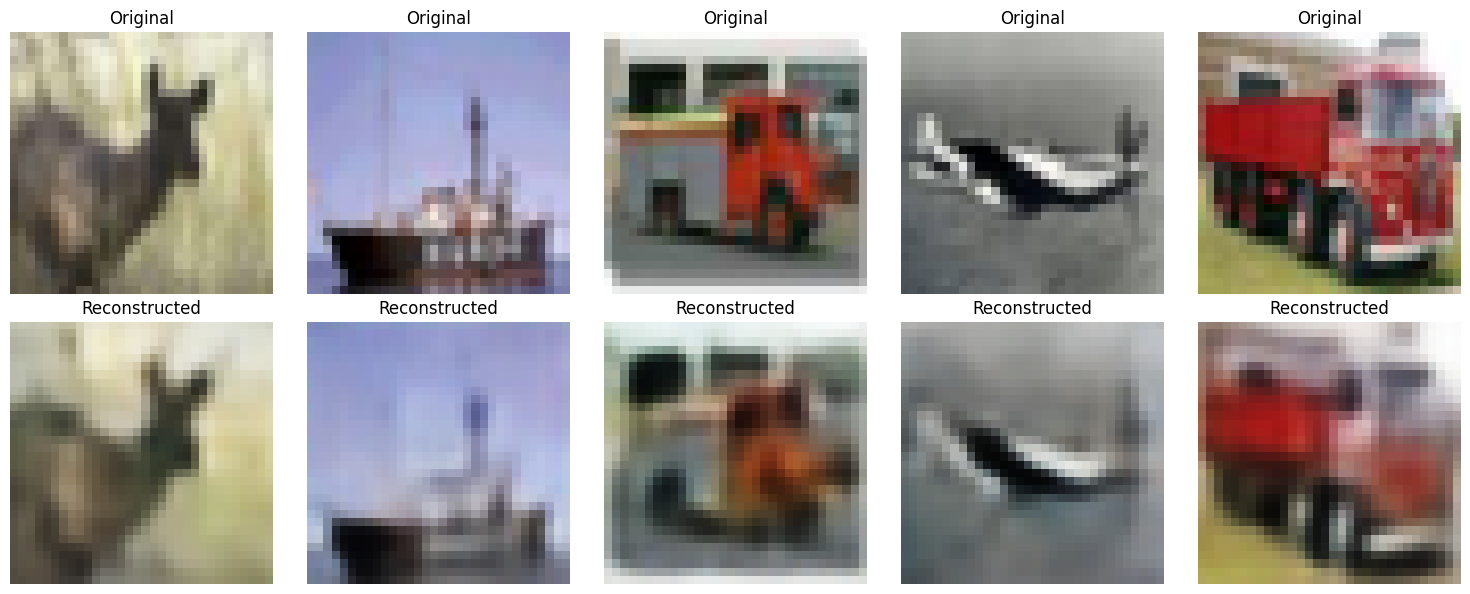

ConvMADVAE(
  (enc_conv1): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_conv3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_conv4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (fc_mu): Linear(in_features=1024, out_features=256, bias=True)
  (fc_logvar): Linear(in_features=1024, out_features=256, bias=True)
  (dec_fc): Linear(in_features=256, out_features=1024, bias=True)
  (dec_conv1): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec_conv2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec_conv3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec_conv4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
)

In [27]:
import matplotlib.pyplot as plt

# Set the VAE to evaluation mode
vae_model.eval()

# Grab a single batch of real images from the dataloader
real_batch = next(iter(dataloader))[0].to(device)

# Pass them through the VAE
with torch.no_grad():
    recon_batch, _, _ = vae_model(real_batch)

# Move them to the CPU for plotting and scale them from [-1, 1] back to [0, 1]
real_images = (real_batch[:5].cpu() + 1) / 2.0
recon_images = (recon_batch[:5].cpu() + 1) / 2.0
real_images = torch.clamp(real_images, 0, 1)
recon_images = torch.clamp(recon_images, 0, 1)

# Plotting
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # Top Row: Real Images
    axes[0, i].imshow(real_images[i].permute(1, 2, 0))
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    
    # Bottom Row: VAE Reconstructions
    axes[1, i].imshow(recon_images[i].permute(1, 2, 0))
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Put it back in training mode just in case
vae_model.train()

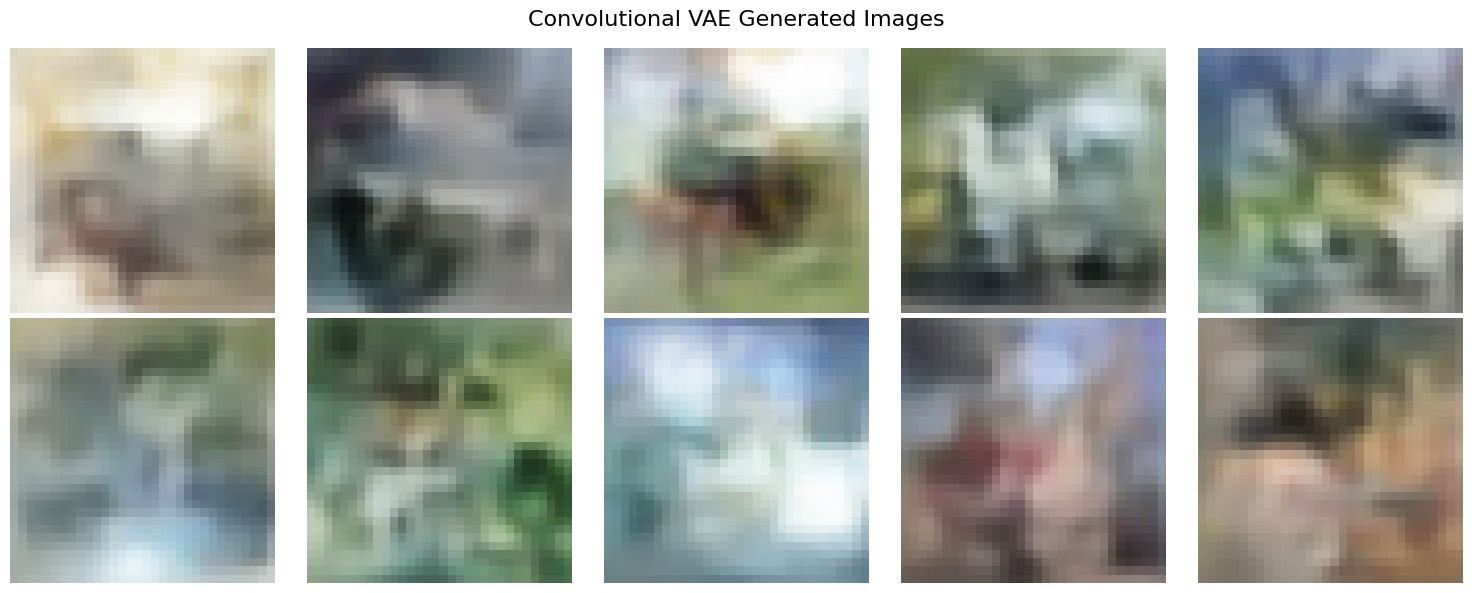

In [25]:
import torch
import matplotlib.pyplot as plt

# 1. Set model to evaluation mode
vae_model.eval()

# 2. Define how many images we want and our latent space size
num_images = 10
z_dim = 256 # This must match the z_dim you set in ConvMADVAE

with torch.no_grad():
    # 3. Sample pure random noise from a standard normal distribution
    random_latent_vectors = torch.randn(num_images, z_dim).to(device)
    
    # 4. Pass the noise directly into the DECODER 
    # Because we are using Conv2d now, the decoder outputs the exact 
    # (10, 3, 32, 32) image shape automatically! No un-flattening needed!
    generated_images = vae_model.decode(random_latent_vectors)

# 5. Move to CPU and scale from [-1, 1] back to [0, 1] for matplotlib
generated_images = (generated_images.cpu() + 1) / 2.0
generated_images = torch.clamp(generated_images, 0.0, 1.0)

# 6. Plot the newly hallucinated images!
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Convolutional VAE Generated Images", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    # Matplotlib expects images in (Height, Width, Channels) format
    img = generated_images[i].permute(1, 2, 0).numpy()
    ax.imshow(img, interpolation='nearest')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:
import torch
from torchmetrics.image.fid import FrechetInceptionDistance

# 1. Initialize the FID metric
fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
vae_model.eval()

@torch.no_grad()
def generate_fake_vae_batch(batch_size, z_dim=256):
    """Generates a batch of fake images directly from latent noise."""
    # Sample random numbers from a normal distribution
    random_latent_vectors = torch.randn(batch_size, z_dim).to(device)
    
    # Pass them through the decoder
    generated_flat_images = vae_model.decode(random_latent_vectors)
    
    # Un-flatten back into 64x64 images
    generated_images = generated_flat_images.view(batch_size, 3, 32, 32)
    return generated_images

def calculate_vae_fid(num_batches=4):
    """
    Calculates FID by comparing real test batches to VAE generated batches.
    """
    print(f"Calculating VAE FID over {num_batches * BATCH_SIZE} images...")
    
    test_iterator = iter(dataloader)
    
    for i in range(num_batches):
        print(f"Processing batch {i+1}/{num_batches}...")
        
        # --- Process Real Images ---
        try:
            real_images = next(test_iterator)[0].to(device)
        except StopIteration:
            test_iterator = iter(dataloader)
            real_images = next(test_iterator)[0].to(device)
            
        # Scale to [0, 1] for the FID metric
        real_images = (real_images + 1) / 2.0
        real_images = torch.clamp(real_images, 0.0, 1.0)
        fid.update(real_images, real=True)
        
        # --- Process Fake Images ---
        fake_images = generate_fake_vae_batch(BATCH_SIZE)
        
        # Scale to [0, 1]
        fake_images = (fake_images + 1) / 2.0
        fake_images = torch.clamp(fake_images, 0.0, 1.0)
        fid.update(fake_images, real=False)

    # Compute final score
    fid_score = fid.compute()
    print(f"\nFinal VAE FID Score: {fid_score.item():.2f}")
    
    fid.reset()
    return fid_score.item()

# Let's run it on 4 batches to match your DDPM test!
calculate_vae_fid(num_batches=32)

Calculating VAE FID over 2048 images...
Processing batch 1/32...
Processing batch 2/32...
Processing batch 3/32...
Processing batch 4/32...
Processing batch 5/32...
Processing batch 6/32...
Processing batch 7/32...
Processing batch 8/32...
Processing batch 9/32...
Processing batch 10/32...
Processing batch 11/32...
Processing batch 12/32...
Processing batch 13/32...
Processing batch 14/32...
Processing batch 15/32...
Processing batch 16/32...
Processing batch 17/32...
Processing batch 18/32...
Processing batch 19/32...
Processing batch 20/32...
Processing batch 21/32...
Processing batch 22/32...
Processing batch 23/32...
Processing batch 24/32...
Processing batch 25/32...
Processing batch 26/32...
Processing batch 27/32...
Processing batch 28/32...
Processing batch 29/32...
Processing batch 30/32...
Processing batch 31/32...
Processing batch 32/32...

Final VAE FID Score: 144.06


144.06353759765625